In [2]:
pip install pyodbc sqlalchemy

Note: you may need to restart the kernel to use updated packages.


In [3]:
# ============================================================
# BANKING ANALYTICS SOLUTION — EXPLORATORY DATA ANALYSIS
# Czechoslovakia Bank | Prepared by: Anurag
# ============================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('seaborn-v0_8')
sns.set_palette('Blues_d')

print("Libraries imported successfully")

Libraries imported successfully


In [4]:
# Connect to SQL Server

SERVER   = 'LAPTOP-4R2V0KCP\SQLEXPRESS'
DATABASE = 'Intership_project'

engine = create_engine(
    f'mssql+pyodbc://{SERVER}/{DATABASE}'
    f'?driver=ODBC+Driver+17+for+SQL+Server'
    f'&trusted_connection=yes'
)

print("Connected to SQL Server successfully")

Connected to SQL Server successfully


In [5]:
# Load All Tables
account    = pd.read_sql("SELECT * FROM account",    engine)
card       = pd.read_sql("SELECT * FROM card",       engine)
client     = pd.read_sql("SELECT * FROM client",     engine)
disp       = pd.read_sql("SELECT * FROM disp",       engine)
district   = pd.read_sql("SELECT * FROM district",   engine)
loan       = pd.read_sql("SELECT * FROM loan",       engine)
order_df   = pd.read_sql("SELECT * FROM [order]",    engine)
fact_table = pd.read_sql("SELECT * FROM fact_table", engine)

print("All tables loaded successfully")
print(f"\nTable sizes:")
print(f"  account:    {len(account):,} rows")
print(f"  card:       {len(card):,} rows")
print(f"  client:     {len(client):,} rows")
print(f"  disp:       {len(disp):,} rows")
print(f"  district:   {len(district):,} rows")
print(f"  loan:       {len(loan):,} rows")
print(f"  order:      {len(order_df):,} rows")
print(f"  fact_table: {len(fact_table):,} rows")

All tables loaded successfully

Table sizes:
  account:    4,500 rows
  card:       892 rows
  client:     5,369 rows
  disp:       5,369 rows
  district:   77 rows
  loan:       682 rows
  order:      6,471 rows
  fact_table: 1,048,575 rows


In [6]:
# Load district with A1 renamed to district_id
district = pd.read_sql("SELECT * FROM district", engine)

# Rename all columns to readable names
district = district.rename(columns={
    'A1'  : 'district_id',
    'A2'  : 'district_name',
    'A3'  : 'region',
    'A4'  : 'population',
    'A5'  : 'num_municipalities',
    'A6'  : 'num_municipalities_small',
    'A7'  : 'num_municipalities_medium',
    'A8'  : 'num_municipalities_large',
    'A9'  : 'num_cities',
    'A10' : 'urban_population_ratio',
    'A11' : 'avg_salary',
    'A12' : 'unemployment_rate',
    'A13' : 'unemployment_rate_prev',
    'A14' : 'num_entrepreneurs',
    'A15' : 'num_crimes_prev',
    'A16' : 'num_crimes'
})

print("District columns renamed successfully")
print(district.columns.tolist())
print(district.head(3))

District columns renamed successfully
['district_id', 'district_name', 'region', 'population', 'num_municipalities', 'num_municipalities_small', 'num_municipalities_medium', 'num_municipalities_large', 'num_cities', 'urban_population_ratio', 'avg_salary', 'unemployment_rate', 'unemployment_rate_prev', 'num_entrepreneurs', 'num_crimes_prev', 'num_crimes']
   district_id district_name           region  population  num_municipalities  \
0            1   Hl.m. Praha           Prague     1204953                   0   
1            2       Benesov  central Bohemia       88884                  80   
2            3        Beroun  central Bohemia       75232                  55   

   num_municipalities_small  num_municipalities_medium  \
0                         0                          0   
1                        26                          6   
2                        26                          4   

   num_municipalities_large  num_cities  urban_population_ratio  avg_salary  \
0     

In [7]:
# ============================================================
# SECTION 1 — CUSTOMER ANALYSIS
# ============================================================

from datetime import datetime

def extract_gender(bn):
    bn = str(bn).zfill(6)
    month = int(bn[2:4])
    return 'Female' if month > 50 else 'Male'

def extract_birth_month(bn):
    bn = str(bn).zfill(6)
    month = int(bn[2:4])
    return month - 50 if month > 50 else month  # actual birth month

def extract_age(bn):
    bn = str(bn).zfill(6)
    year = 1900 + int(bn[:2])
    return datetime.now().year - year  # current year

# Apply all three
client['gender']       = client['birth_number'].apply(extract_gender)
client['birth_month']  = client['birth_number'].apply(extract_birth_month)
client['age']          = client['birth_number'].apply(extract_age)
client['age_group']    = pd.cut(
    client['age'],
    bins=[0, 30, 45, 60, 100],
    labels=['18-30', '31-45', '46-60', '60+']
)


print(f"Current year used: {datetime.now().year}")
print(client[['client_id','birth_number','gender','birth_month','age']].head(10))

print("Gender and Age extracted")
print(f"\nGender Distribution:")
print(client['gender'].value_counts())
print(f"\nAge Statistics:")
print(client['age'].describe().round(1))

Current year used: 2026
   client_id  birth_number  gender  birth_month  age
0          1        706213  Female           12   56
1          2        450204    Male            2   81
2          3        406009  Female           10   86
3          4        561201    Male           12   70
4          5        605703  Female            7   66
5          6        190922    Male            9  107
6          7        290125    Male            1   97
7          8        385221  Female            2   88
8          9        351016    Male           10   91
9         10        430501    Male            5   83
Gender and Age extracted

Gender Distribution:
gender
Male      2724
Female    2645
Name: count, dtype: int64

Age Statistics:
count    5369.0
mean       72.8
std        17.3
min        39.0
25%        58.0
50%        72.0
75%        86.0
max       115.0
Name: age, dtype: float64


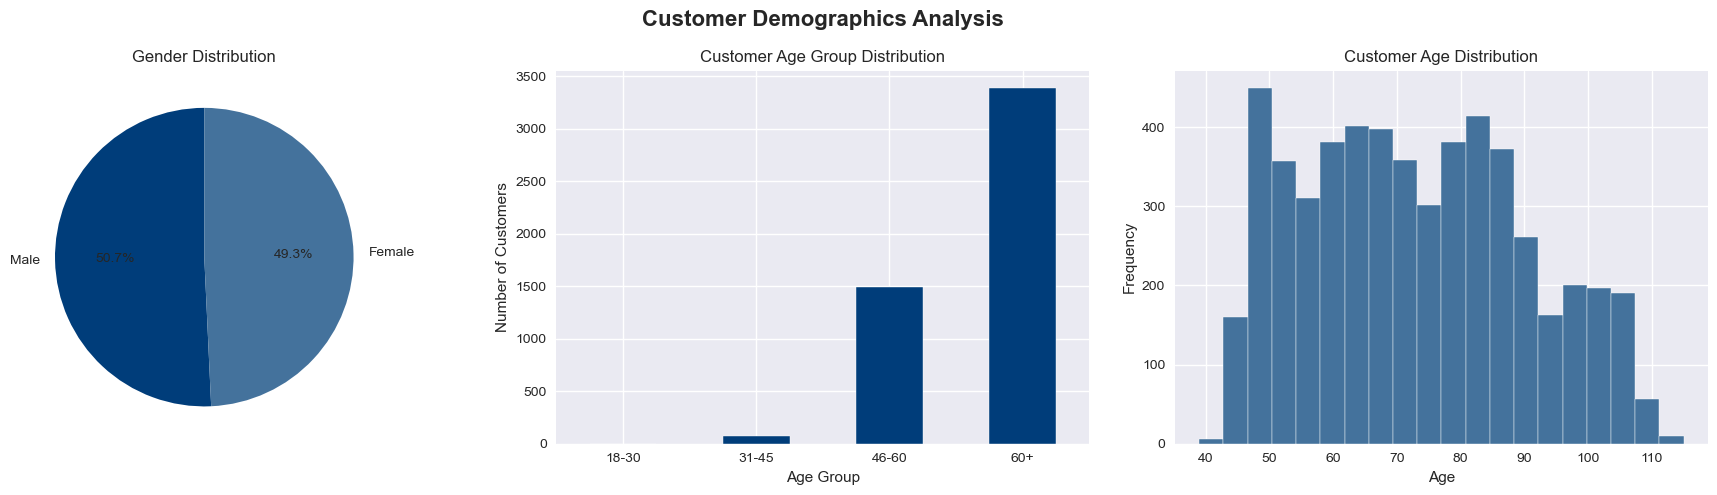

Customer demographics chart saved


In [8]:
# Customer Demographics Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Customer Demographics Analysis', fontsize=16, fontweight='bold')

# Gender distribution
client['gender'].value_counts().plot(
    kind='pie', ax=axes[0],
    autopct='%1.1f%%',
    colors=['#003D7A', '#44729C'],
    startangle=90
)
axes[0].set_title('Gender Distribution')
axes[0].set_ylabel('')

# Age group distribution
client['age_group'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1],
    color='#003D7A', edgecolor='white'
)
axes[1].set_title('Customer Age Group Distribution')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Number of Customers')
axes[1].tick_params(rotation=0)

# Age histogram
axes[2].hist(client['age'], bins=20, color='#44729C', edgecolor='white')
axes[2].set_title('Customer Age Distribution')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('customer_demographics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Customer demographics chart saved")

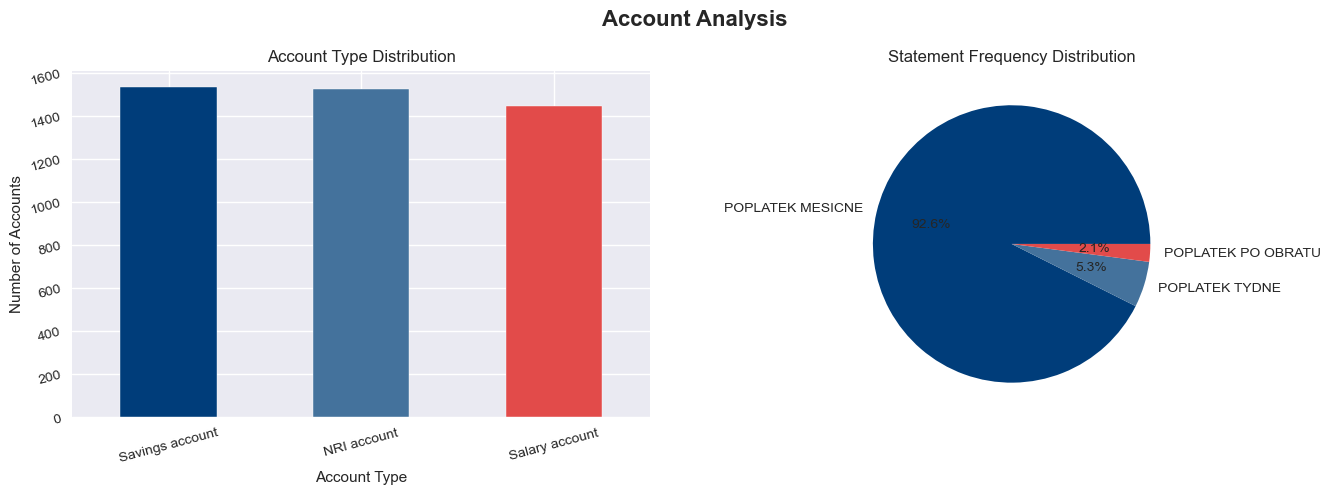

In [9]:
# ============================================================
# SECTION 2 — ACCOUNT ANALYSIS
# ============================================================

# Account Type and Frequency Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Account Analysis', fontsize=16, fontweight='bold')

# Account type
account['Account_type'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#003D7A', '#44729C', '#E24B4A'],
    edgecolor='white'
)
axes[0].set_title('Account Type Distribution')
axes[0].set_xlabel('Account Type')
axes[0].set_ylabel('Number of Accounts')
axes[0].tick_params(rotation=15)

# Statement frequency
account['frequency'].value_counts().plot(
    kind='pie', ax=axes[1],
    autopct='%1.1f%%',
    colors=['#003D7A', '#44729C', '#E24B4A']
)
axes[1].set_title('Statement Frequency Distribution')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('account_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ============================================================
# SECTION 3 — TRANSACTION ANALYSIS
# ============================================================

# Convert Date and Extract Time Features
fact_table['Date'] = pd.to_datetime(fact_table['Date'])
fact_table['Year']  = fact_table['Date'].dt.year
fact_table['Month'] = fact_table['Date'].dt.month
fact_table['MonthName'] = fact_table['Date'].dt.strftime('%b')

print("Date features extracted")
print(f"\nTransaction date range:")
print(f"  From: {fact_table['Date'].min().date()}")
print(f"  To:   {fact_table['Date'].max().date()}")
print(f"\nTransactions by Year:")
print(fact_table['Year'].value_counts().sort_index())

Date features extracted

Transaction date range:
  From: 2016-01-01
  To:   2021-12-19

Transactions by Year:
Year
2016     28205
2017     91628
2018    133022
2019    196779
2020    284409
2021    314532
Name: count, dtype: int64


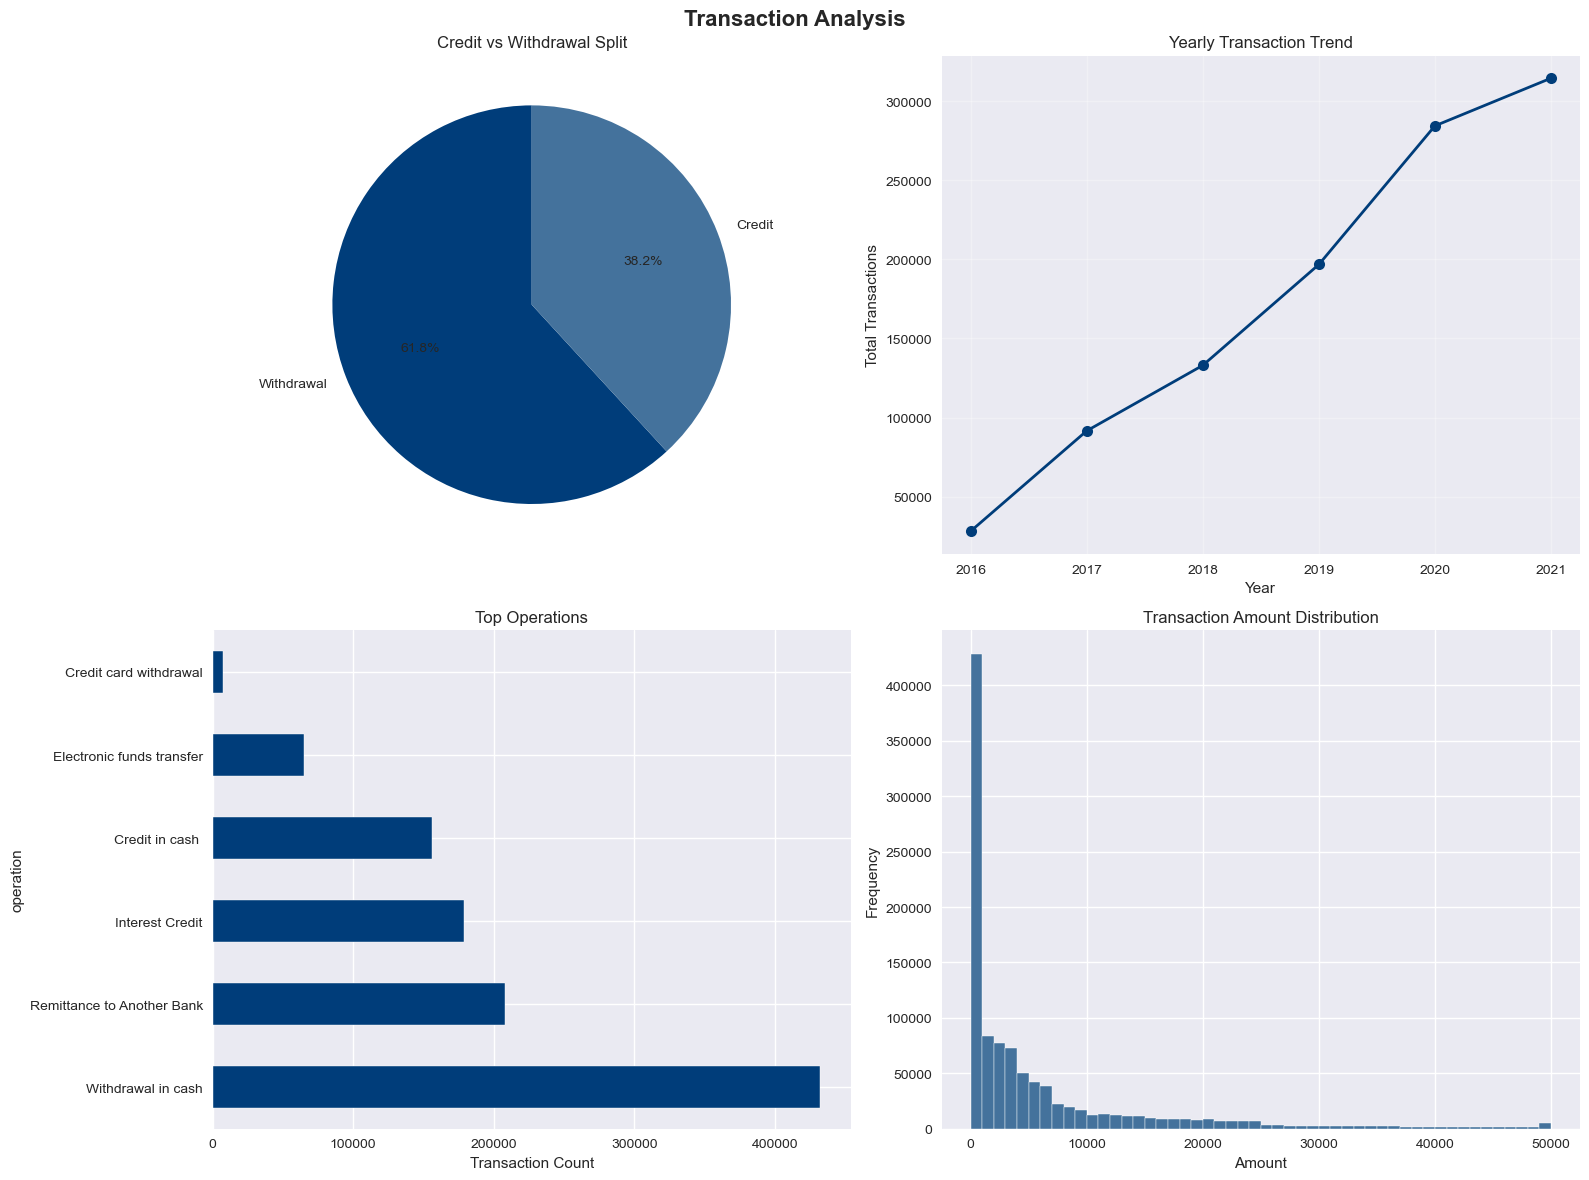

In [11]:
# Transaction Type Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Transaction Analysis', fontsize=16, fontweight='bold')

# Credit vs Withdrawal
fact_table['Type'].value_counts().plot(
    kind='pie', ax=axes[0,0],
    autopct='%1.1f%%',
    colors=['#003D7A', '#44729C'],
    startangle=90
)
axes[0,0].set_title('Credit vs Withdrawal Split')
axes[0,0].set_ylabel('')

# Yearly transaction trend
yearly = fact_table.groupby('Year').size().reset_index(name='count')
axes[0,1].plot(
    yearly['Year'], yearly['count'],
    marker='o', color='#003D7A',
    linewidth=2, markersize=8
)
axes[0,1].set_title('Yearly Transaction Trend')
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('Total Transactions')
axes[0,1].grid(True, alpha=0.3)

# Operation type breakdown
top_ops = fact_table['operation'].value_counts().head(6)
top_ops.plot(
    kind='barh', ax=axes[1,0],
    color='#003D7A', edgecolor='white'
)
axes[1,0].set_title('Top Operations')
axes[1,0].set_xlabel('Transaction Count')

# Amount distribution
axes[1,1].hist(
    fact_table['amount'].clip(upper=50000),
    bins=50, color='#44729C', edgecolor='white'
)
axes[1,1].set_title('Transaction Amount Distribution')
axes[1,1].set_xlabel('Amount')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('transaction_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ============================================================
# SECTION 4 — LOAN ANALYSIS
# ============================================================

# Loan Portfolio Overview
print("=" * 50)
print("LOAN PORTFOLIO SUMMARY")
print("=" * 50)
print(f"Total Loans:        {len(loan):,}")
print(f"Total Loan Value:   {loan['amount'].sum():,.0f}")
print(f"Average Loan:       {loan['amount'].mean():,.0f}")
print(f"Min Loan:           {loan['amount'].min():,.0f}")
print(f"Max Loan:           {loan['amount'].max():,.0f}")

print(f"\nLoan Status Breakdown:")
status_map = {'A':'Running-OK','B':'Running-Bad','C':'Finished-OK','D':'Finished-Bad'}
status_counts = loan['status'].value_counts()
for status, count in status_counts.items():
    pct = count/len(loan)*100
    print(f"  {status} ({status_map[status]}): {count} ({pct:.1f}%)")

bad_loans = loan[loan['status'].isin(['B','D'])]
print(f"\nBad Loans (B+D):    {len(bad_loans)} ({len(bad_loans)/len(loan)*100:.1f}%)")

LOAN PORTFOLIO SUMMARY
Total Loans:        682
Total Loan Value:   103,261,740
Average Loan:       151,410
Min Loan:           4,980
Max Loan:           590,820

Loan Status Breakdown:
  C (Finished-OK): 403 (59.1%)
  A (Running-OK): 203 (29.8%)
  D (Finished-Bad): 45 (6.6%)
  B (Running-Bad): 31 (4.5%)

Bad Loans (B+D):    76 (11.1%)


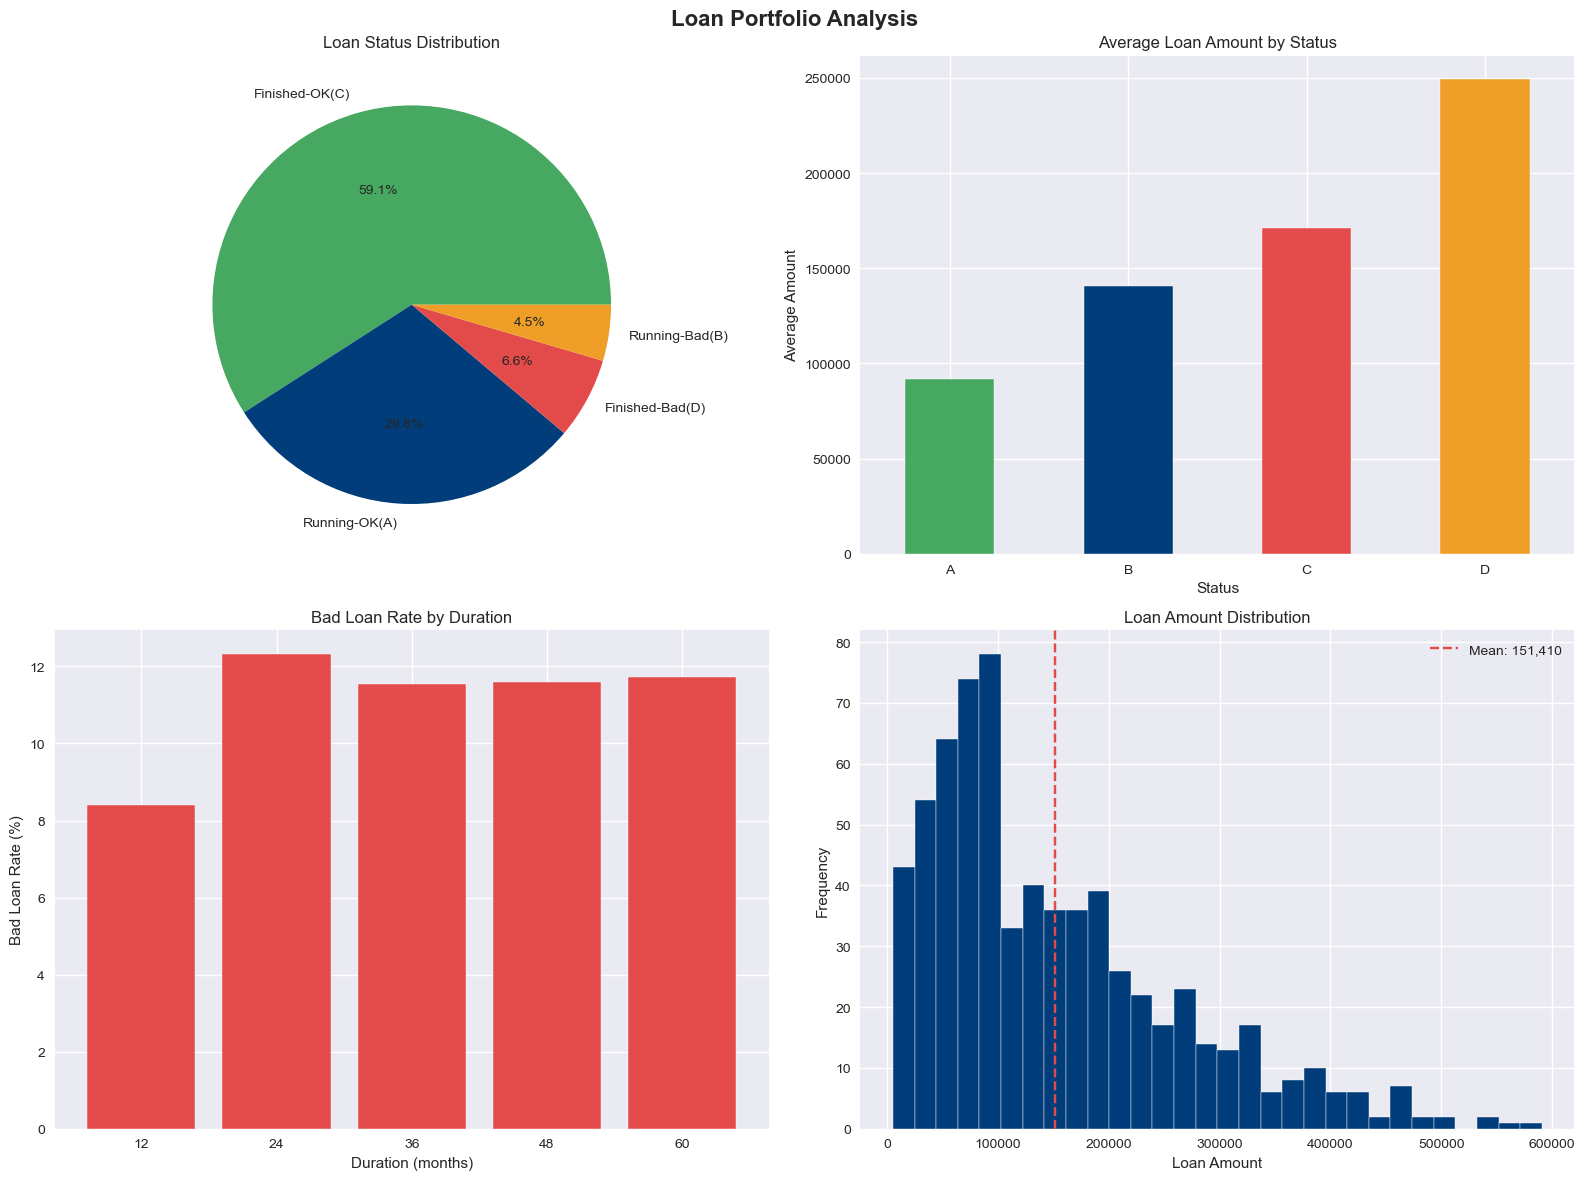

In [13]:
# Loan Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Loan Portfolio Analysis', fontsize=16, fontweight='bold')

# Loan status distribution
colors = ['#46A861','#003D7A','#E24B4A','#EF9F27']
loan['status'].value_counts().plot(
    kind='pie', ax=axes[0,0],
    autopct='%1.1f%%',
    colors=colors,
    labels=['Finished-OK(C)','Running-OK(A)','Finished-Bad(D)','Running-Bad(B)']
)
axes[0,0].set_title('Loan Status Distribution')
axes[0,0].set_ylabel('')

# Loan amount by status
loan.groupby('status')['amount'].mean().plot(
    kind='bar', ax=axes[0,1],
    color=['#46A861','#003D7A','#E24B4A','#EF9F27'],
    edgecolor='white'
)
axes[0,1].set_title('Average Loan Amount by Status')
axes[0,1].set_xlabel('Status')
axes[0,1].set_ylabel('Average Amount')
axes[0,1].tick_params(rotation=0)

# Bad loan rate by duration
bad_rate = loan.groupby('duration').apply(
    lambda x: (x['status'].isin(['B','D']).sum() / len(x)) * 100
).reset_index(name='bad_rate')
axes[1,0].bar(
    bad_rate['duration'].astype(str),
    bad_rate['bad_rate'],
    color='#E24B4A', edgecolor='white'
)
axes[1,0].set_title('Bad Loan Rate by Duration')
axes[1,0].set_xlabel('Duration (months)')
axes[1,0].set_ylabel('Bad Loan Rate (%)')

# Loan amount distribution
axes[1,1].hist(
    loan['amount'], bins=30,
    color='#003D7A', edgecolor='white'
)
axes[1,1].set_title('Loan Amount Distribution')
axes[1,1].set_xlabel('Loan Amount')
axes[1,1].set_ylabel('Frequency')
axes[1,1].axvline(
    loan['amount'].mean(),
    color='#E24B4A', linestyle='--',
    label=f"Mean: {loan['amount'].mean():,.0f}"
)
axes[1,1].legend()

plt.tight_layout()
plt.savefig('loan_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

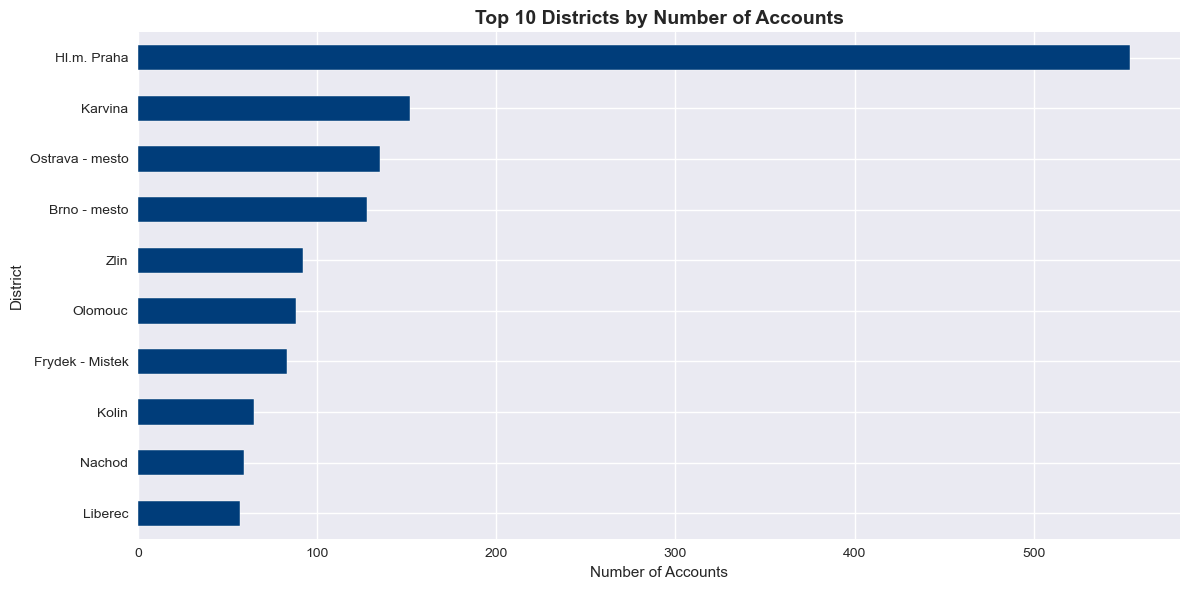


Top 10 Districts:
district_name
Hl.m. Praha        554
Karvina            152
Ostrava - mesto    135
Brno - mesto       128
Zlin                92
Olomouc             88
Frydek - Mistek     83
Kolin               65
Nachod              59
Liberec             57
Name: count, dtype: int64


In [14]:
# ============================================================
# SECTION 5 — DISTRICT ANALYSIS
# ============================================================

# Merge district with account for regional analysis
district_account = account.merge(
    district[['district_id', 'district_name', 'avg_salary', 'unemployment_rate']],
    on='district_id',
    how='left'
)

# Top 10 districts by accounts
top_districts = district_account['district_name'].value_counts().head(10)

plt.figure(figsize=(12, 6))
top_districts.sort_values().plot(
    kind='barh',
    color='#003D7A',
    edgecolor='white'
)
plt.title('Top 10 Districts by Number of Accounts', fontsize=14, fontweight='bold')
plt.xlabel('Number of Accounts')
plt.ylabel('District')
plt.tight_layout()
plt.savefig('district_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 Districts:")
print(top_districts)

In [15]:
# ============================================================
# SECTION 6 — EDA SUMMARY
# ============================================================

# Print complete EDA summary
print("=" * 60)
print("   BANKING EDA SUMMARY — CZECHOSLOVAKIA BANK")
print("=" * 60)

print(f"\n CUSTOMERS")
print(f"   Total Clients:     {len(client):,}")
print(f"   Male:              {(client['gender']=='Male').sum():,} ({(client['gender']=='Male').mean()*100:.1f}%)")
print(f"   Female:            {(client['gender']=='Female').sum():,} ({(client['gender']=='Female').mean()*100:.1f}%)")
print(f"   Average Age:       {client['age'].mean():.0f} years")

print(f"\n ACCOUNTS")
print(f"   Total Accounts:    {len(account):,}")
print(f"   Savings:           {(account['Account_type']=='Savings account').sum():,}")
print(f"   Salary:            {(account['Account_type']=='Salary account').sum():,}")
print(f"   NRI:               {(account['Account_type']=='NRI account').sum():,}")

print(f"\n CARDS")
print(f"   Total Cards:       {len(card):,}")
print(f"   Classic:           {(card['type']=='classic').sum():,}")
print(f"   Junior:            {(card['type']=='junior').sum():,}")
print(f"   Gold:              {(card['type']=='gold').sum():,}")
print(f"   Adoption Rate:     {len(card)/len(client)*100:.1f}%")

print(f"\n TRANSACTIONS")
print(f"   Total:             {len(fact_table):,}")
print(f"   Credits:           {(fact_table['Type']=='Credit').sum():,}")
print(f"   Withdrawals:       {(fact_table['Type']=='Withdrawal').sum():,}")
print(f"   Avg Amount:        {fact_table['amount'].mean():,.0f}")
print(f"   Avg Balance:       {fact_table['balance'].mean():,.0f}")

print(f"\n LOANS")
print(f"   Total Loans:       {len(loan):,}")
print(f"   Bad Loans:         {loan['status'].isin(['B','D']).sum():,}")
print(f"   Default Rate:      {loan['status'].isin(['B','D']).mean()*100:.1f}%")
print(f"   Avg Loan Amount:   {loan['amount'].mean():,.0f}")

print(f"\n GEOGRAPHY")
print(f"   Total Districts:   {district['district_id'].nunique():,}")
print(f"   Top District:      Hl.m. Praha")

print("\n" + "=" * 60)
print("EDA COMPLETE — Ready for Predictive Modeling")
print("=" * 60)

   BANKING EDA SUMMARY — CZECHOSLOVAKIA BANK

 CUSTOMERS
   Total Clients:     5,369
   Male:              2,724 (50.7%)
   Female:            2,645 (49.3%)
   Average Age:       73 years

 ACCOUNTS
   Total Accounts:    4,500
   Savings:           1,533
   Salary:            1,445
   NRI:               1,522

 CARDS
   Total Cards:       892
   Classic:           659
   Junior:            145
   Gold:              88
   Adoption Rate:     16.6%

 TRANSACTIONS
   Total:             1,048,575
   Credits:           400,209
   Withdrawals:       648,366
   Avg Amount:        5,942
   Avg Balance:       38,457

 LOANS
   Total Loans:       682
   Bad Loans:         76
   Default Rate:      11.1%
   Avg Loan Amount:   151,410

 GEOGRAPHY
   Total Districts:   77
   Top District:      Hl.m. Praha

EDA COMPLETE — Ready for Predictive Modeling


# ============================================================
# PART 2 — PREDICTIVE MODELING
# Loan Default Prediction
# ============================================================

In [16]:
# ============================================================
# PREDICTIVE MODELING — LOAN DEFAULT PREDICTION
# ============================================================

# Import additional libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import pickle

print("ML libraries imported")

ML libraries imported


In [17]:
# Build Account-Level Transaction Features
account_txn_features = fact_table.groupby('account_id').agg(
    avg_balance=('balance', 'mean'),
    min_balance=('balance', 'min'),
    max_balance=('balance', 'max'),
    total_transactions=('trans_id', 'count'),
    avg_transaction_amount=('amount', 'mean'),
    total_credits=('Type', lambda x: (x == 'Credit').sum()),
    total_withdrawals=('Type', lambda x: (x == 'Withdrawal').sum())
).reset_index()

account_txn_features['credit_withdrawal_ratio'] = (
    account_txn_features['total_credits'] / 
    account_txn_features['total_withdrawals'].replace(0, 1)
)

print("Account transaction features created")
print(account_txn_features.head())

Account transaction features created
   account_id   avg_balance  min_balance  max_balance  total_transactions  \
0           1  16004.628151       1000.0      30414.8                 238   
1           2  36527.942558       1100.0      69302.0                 477   
2           3  26555.806087       1000.0      53446.5                 115   
3           4  21688.758378        800.0      34870.0                 185   
4           5  24971.544444        600.0      32036.2                  81   

   avg_transaction_amount  total_credits  total_withdrawals  \
0             1576.214286            101                137   
1             6606.618449            151                326   
2             2541.391304             45                 70   
3             1896.486486             64                121   
4             2047.148148             34                 47   

   credit_withdrawal_ratio  
0                 0.737226  
1                 0.463190  
2                 0.642857  
3    

In [18]:
# Build Client-Level Features (age, district economics)
client_features = client.merge(
    district[['district_id', 'avg_salary', 'unemployment_rate']],
    on='district_id', how='left'
)
client_features = client_features[['client_id', 'age', 'gender', 'avg_salary', 'unemployment_rate']]
print("Client features created")
print(client_features.head())

Client features created
   client_id  age  gender  avg_salary  unemployment_rate
0          1   56  Female        8968               2.83
1          2   81    Male       12541               0.29
2          3   86  Female       12541               0.29
3          4   70    Male        9307               3.85
4          5   66  Female        9307               3.85


In [19]:
# Link Client to Account (via disp — OWNER only)
owner_disp = disp[disp['type'] == 'OWNER'][['account_id', 'client_id']]

account_client = owner_disp.merge(client_features, on='client_id', how='left')

print("Account-Client mapping created")
print(account_client.head())

Account-Client mapping created
   account_id  client_id  age  gender  avg_salary  unemployment_rate
0           1          1   56  Female        8968               2.83
1           2          2   81    Male       12541               0.29
2           3          4   70    Male        9307               3.85
3           4          6  107    Male        8754               3.83
4           5          7   97    Male        9045               3.13


In [20]:
# Build Final Model Dataset (one row per loan)
model_df = loan.copy()

# Add account transaction features
model_df = model_df.merge(account_txn_features, on='account_id', how='left')

# Add client demographic features
model_df = model_df.merge(account_client, on='account_id', how='left')

# Add card ownership flag
card_accounts = card.merge(disp[['disp_id','account_id']], on='disp_id')['account_id'].unique()
model_df['has_card'] = model_df['account_id'].isin(card_accounts).astype(int)

# Create target variable — Bad Loan = 1, Good Loan = 0
model_df['default'] = model_df['status'].isin(['B', 'D']).astype(int)

print("Final model dataset created")
print(f"Shape: {model_df.shape}")
print(f"\nTarget distribution:")
print(model_df['default'].value_counts())
print(f"Default rate: {model_df['default'].mean()*100:.1f}%")

model_df.head()

Final model dataset created
Shape: (682, 22)

Target distribution:
default
0    606
1     76
Name: count, dtype: int64
Default rate: 11.1%


,loan_id,account_id,date,amount,duration,payments,status,avg_balance,min_balance,max_balance,...,total_credits,total_withdrawals,credit_withdrawal_ratio,client_id,age,gender,avg_salary,unemployment_rate,has_card,default
0,4959,2,1994-01-05,80952,24,3373,A,36527.942558,1100.0,69302.0,...,151,326,0.463190,2,81,Male,12541,0.29,0,0
1,4961,19,1996-04-29,30276,12,2523,B,16288.927243,-10604.7,58157.5,...,150,151,0.993377,25,87,Female,9104,1.51,0,1
2,4962,25,1997-12-08,30276,12,2523,A,56471.616912,900.0,134209.9,...,81,191,0.424084,31,64,Male,9893,4.09,0,0
3,4967,37,1998-10-14,318480,60,5308,D,37417.641406,-1011.2,104761.5,...,35,93,0.376344,45,74,Male,8547,2.65,0,1
4,4968,38,1998-04-19,110736,48,2307,C,34383.792248,13841.0,55991.1,...,47,82,0.573171,46,86,Female,8402,3.13,0,0


In [21]:
# Check for Missing Values
print("Missing values per column:")
print(model_df.isnull().sum())

# Fill any missing values with median (numeric) or mode (categorical)
numeric_cols = model_df.select_dtypes(include=[np.number]).columns
model_df[numeric_cols] = model_df[numeric_cols].fillna(model_df[numeric_cols].median())

print("\nMissing values handled")

Missing values per column:
loan_id                    0
account_id                 0
date                       0
amount                     0
duration                   0
payments                   0
status                     0
avg_balance                0
min_balance                0
max_balance                0
total_transactions         0
avg_transaction_amount     0
total_credits              0
total_withdrawals          0
credit_withdrawal_ratio    0
client_id                  0
age                        0
gender                     0
avg_salary                 0
unemployment_rate          8
has_card                   0
default                    0
dtype: int64

Missing values handled


In [22]:
# Select Final Features
# Removed:
#   - 'payments'    -> redundant, = amount/duration exactly
#   - 'min_balance' -> data leakage, negative only after default occurs

feature_cols = [
    'amount', 'duration',
    'avg_balance', 'max_balance',
    'total_transactions', 'avg_transaction_amount',
    'credit_withdrawal_ratio',
    'age', 'avg_salary', 'unemployment_rate',
    'has_card'
]

X = model_df[feature_cols]
y = model_df['default']

print(f"Features: {feature_cols}")
print(f"X shape: {X.shape}")

Features: ['amount', 'duration', 'avg_balance', 'max_balance', 'total_transactions', 'avg_transaction_amount', 'credit_withdrawal_ratio', 'age', 'avg_salary', 'unemployment_rate', 'has_card']
X shape: (682, 11)


In [23]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} loans")
print(f"Test set:     {X_test.shape[0]} loans")
print(f"\nTraining default rate: {y_train.mean()*100:.1f}%")
print(f"Test default rate:     {y_test.mean()*100:.1f}%")

Training set: 545 loans
Test set:     137 loans

Training default rate: 11.2%
Test default rate:     10.9%


In [24]:
# Scale Features (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Features scaled")

Features scaled


### Model 1: Logistic Regression ###

In [25]:
# Train Logistic Regression
log_reg = LogisticRegression(random_state=42, class_weight='balanced')
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.3f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_lr):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_lr):.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION RESULTS
Accuracy:  0.883
Precision: 0.478
Recall:    0.733
F1 Score:  0.579
ROC-AUC:   0.896

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.90      0.93       122
           1       0.48      0.73      0.58        15

    accuracy                           0.88       137
   macro avg       0.72      0.82      0.76       137
weighted avg       0.91      0.88      0.89       137



### Model 2: Random Forest ###

In [26]:
# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train, y_train)  # Random Forest doesn't need scaled data

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.3f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_rf):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_rf):.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST RESULTS
Accuracy:  0.898
Precision: 0.571
Recall:    0.267
F1 Score:  0.364
ROC-AUC:   0.804

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.94       122
           1       0.57      0.27      0.36        15

    accuracy                           0.90       137
   macro avg       0.74      0.62      0.65       137
weighted avg       0.88      0.90      0.88       137



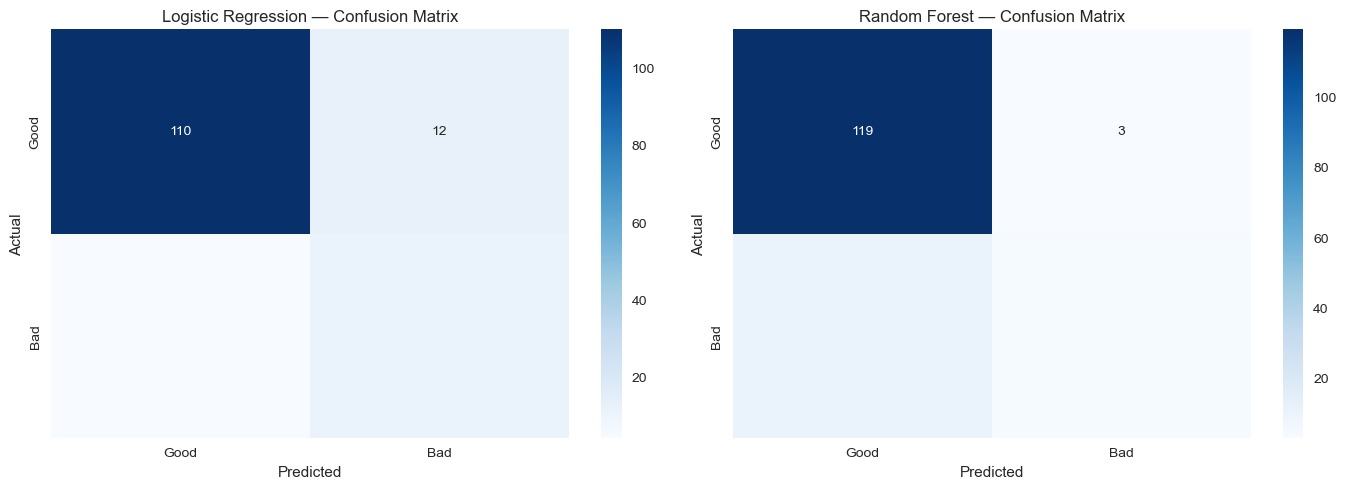

In [27]:
# Confusion Matrices Side by Side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Good','Bad'], yticklabels=['Good','Bad'])
axes[0].set_title('Logistic Regression — Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Good','Bad'], yticklabels=['Good','Bad'])
axes[1].set_title('Random Forest — Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

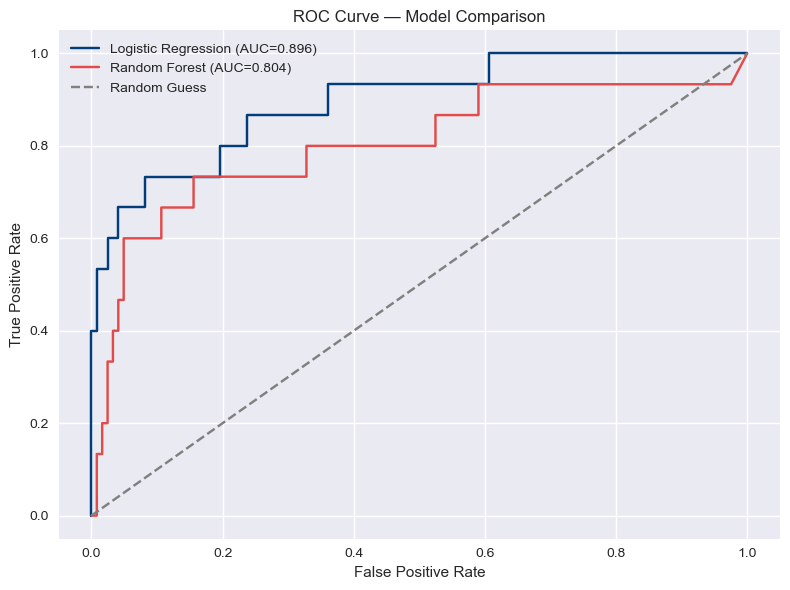

In [28]:
# ROC Curve Comparison
fig, ax = plt.subplots(figsize=(8, 6))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_score(y_test, y_proba_lr):.3f})', color='#003D7A')
ax.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test, y_proba_rf):.3f})', color='#E24B4A')
ax.plot([0,1],[0,1], linestyle='--', color='gray', label='Random Guess')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Model Comparison')
ax.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

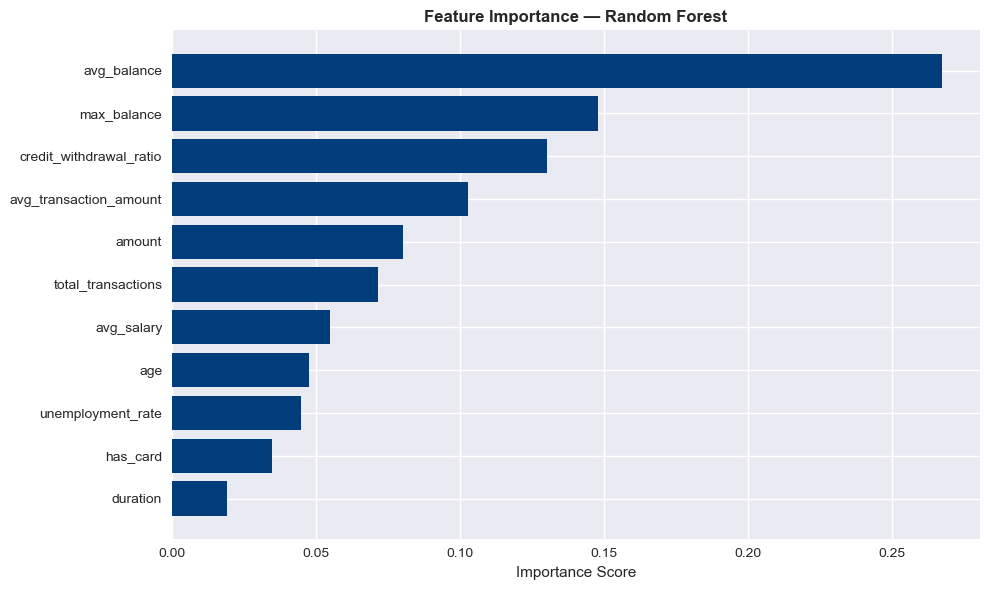

                    feature  importance
2               avg_balance    0.267050
3               max_balance    0.147726
6   credit_withdrawal_ratio    0.129991
5    avg_transaction_amount    0.102633
0                    amount    0.080071
4        total_transactions    0.071626
8                avg_salary    0.054958
7                       age    0.047382
9         unemployment_rate    0.044720
10                 has_card    0.034816
1                  duration    0.019026


In [29]:
# Which Features Matter Most?
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'], color='#003D7A')
plt.xlabel('Importance Score')
plt.title('Feature Importance — Random Forest', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(importance_df)

In [30]:
# Save Logistic Regression Model
with open('loan_default_model.pkl', 'wb') as f:
    pickle.dump(log_reg, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model saved as loan_default_model.pkl (Logistic Regression)")
print("Scaler saved as scaler.pkl")
print(f"\nFinal Model Performance:")
print(f"  Accuracy:  88.3%")
print(f"  Recall:    73.3% (catches 11 of 15 actual defaults)")
print(f"  ROC-AUC:   0.896")

Model saved as loan_default_model.pkl (Logistic Regression)
Scaler saved as scaler.pkl

Final Model Performance:
  Accuracy:  88.3%
  Recall:    73.3% (catches 11 of 15 actual defaults)
  ROC-AUC:   0.896


In [31]:
import os
print("loan_default_model.pkl exists:", os.path.exists('loan_default_model.pkl'))
print("scaler.pkl exists:", os.path.exists('scaler.pkl'))
print("\nFiles in current folder:")
print([f for f in os.listdir() if f.endswith('.pkl')])

loan_default_model.pkl exists: True
scaler.pkl exists: True

Files in current folder:
['loan_default_model.pkl', 'scaler.pkl']


In [32]:
# Export data for Streamlit app
import os

# Create a folder for app data if it doesn't exist
os.makedirs('app_data', exist_ok=True)

# 1. Export the full model dataset (for dropdown + auto-fill features)
model_df.to_csv('app_data/model_dataset.csv', index=False)

# 2. Export key EDA summary tables for the dashboard tab
client.to_csv('app_data/client.csv', index=False)
account.to_csv('app_data/account.csv', index=False)
loan.to_csv('app_data/loan.csv', index=False)
fact_table.to_csv('app_data/fact_table_sample.csv', index=False)  # full table, may be large
district.to_csv('app_data/district.csv', index=False)
card.to_csv('app_data/card.csv', index=False)

print("All data exported to app_data/ folder")
print(f"\nmodel_dataset.csv shape: {model_df.shape}")
print(f"Columns: {model_df.columns.tolist()}")

All data exported to app_data/ folder

model_dataset.csv shape: (682, 22)
Columns: ['loan_id', 'account_id', 'date', 'amount', 'duration', 'payments', 'status', 'avg_balance', 'min_balance', 'max_balance', 'total_transactions', 'avg_transaction_amount', 'total_credits', 'total_withdrawals', 'credit_withdrawal_ratio', 'client_id', 'age', 'gender', 'avg_salary', 'unemployment_rate', 'has_card', 'default']
